# 1. Imports

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [3]:
PROV_CLM = ("02", "13", "16", "19", "45")

In [4]:
df = pd.read_csv("data/pob_clm.csv", dtype={"cod_mun": str, "cod_prov": str})
df.head()

,cod_mun,periodo,nombre,hombres,mujeres,total,n_ext,n_dif_ca,n_dif_prov,n_dif_mun,n_en_mun,ed_65+,ed_16_64,ed_0_15,altas_ext,altas_int,bajas_ext,bajas_int,edu_primaria_inf,edu_superior,edu_secundaria_1,edu_secundaria_2,act_inactivo,act_ocupado,act_parado,sp_cuenta_ajena_y_otros,sp_cuenta_propia,ae_agricultura_ganaderia_pesca,ae_construccion,ae_industria,ae_no_consta,ae_servicios,mnp_crecimiento_veg,mnp_fallecidos,mnp_matrimonios,mnp_nacimientos,cod_prov,superficie,perimetro,lon,lat
0,02,2000,Albacete,180311.0,182952.0,363263.0,4229.0,33134.0,9017.0,72544.0,244339.0,64596.0,232715.0,65952.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02,14931.74,NaN,NaN,NaN
1,02,2001,Albacete,182826.0,184457.0,367283.0,7560.0,33336.0,9113.0,74643.0,242631.0,65957.0,236246.0,65080.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02,14931.74,NaN,NaN,NaN
2,02,2002,Albacete,185458.0,186329.0,371787.0,11968.0,33561.0,9160.0,74192.0,242906.0,67020.0,240043.0,64724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02,14931.74,NaN,NaN,NaN
3,02,2003,Albacete,188139.0,188417.0,376556.0,15777.0,33995.0,9348.0,73829.0,243607.0,67861.0,243724.0,64971.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02,14931.74,NaN,NaN,NaN
4,02,2004,Albacete,189743.0,189705.0,379448.0,18509.0,34283.0,9451.0,73507.0,243698.0,68315.0,246642.0,64491.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02,14931.74,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24024 entries, 0 to 24023
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   cod_mun                         24024 non-null  str    
 1   periodo                         24024 non-null  int64  
 2   nombre                          24024 non-null  str    
 3   hombres                         24023 non-null  float64
 4   mujeres                         24023 non-null  float64
 5   total                           24023 non-null  float64
 6   n_ext                           24002 non-null  float64
 7   n_dif_ca                        24002 non-null  float64
 8   n_dif_prov                      24002 non-null  float64
 9   n_dif_mun                       24002 non-null  float64
 10  n_en_mun                        24002 non-null  float64
 11  ed_65+                          24002 non-null  float64
 12  ed_16_64                        24002 non-n

In [6]:
display(
    df.notna().groupby(df["periodo"]).sum().drop(columns=["periodo", "cod_mun", "n_ext"])
    .style.background_gradient(vmin=0, vmax=924, cmap="Reds_r")
    # .format("{:.4f}")
)

,nombre,hombres,mujeres,total,n_dif_ca,n_dif_prov,n_dif_mun,n_en_mun,ed_65+,ed_16_64,ed_0_15,altas_ext,altas_int,bajas_ext,bajas_int,edu_primaria_inf,edu_superior,edu_secundaria_1,edu_secundaria_2,act_inactivo,act_ocupado,act_parado,sp_cuenta_ajena_y_otros,sp_cuenta_propia,ae_agricultura_ganaderia_pesca,ae_construccion,ae_industria,ae_no_consta,ae_servicios,mnp_crecimiento_veg,mnp_fallecidos,mnp_matrimonios,mnp_nacimientos,cod_prov,superficie,perimetro,lon,lat
periodo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000,924,923,923,923,914,914,914,914,914,914,914,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2001,924,924,924,924,918,918,918,918,918,918,918,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2002,924,924,924,924,918,918,918,918,918,918,918,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2003,924,924,924,924,924,924,924,924,924,924,924,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2004,924,924,924,924,924,924,924,924,924,924,924,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2005,924,924,924,924,924,924,924,924,924,924,924,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2006,924,924,924,924,924,924,924,924,924,924,924,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2007,924,924,924,924,924,924,924,924,924,924,924,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919
2008,924,924,924,924,924,924,924,924,924,924,924,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,924,924,919,919,919


In [7]:
df[["cod_mun", "cod_prov"]].drop_duplicates().groupby("cod_prov").count()

,cod_mun
cod_prov,
02,88
13,103
16,239
19,289
45,205


# 2. Altas y bajas totales por provincia

## 2.1. Años en los que se registran interiores y exteriores (2021-2024)

Se calculan a partir de las recogidas

In [8]:
# df["altas_total"] = df["altas_total"].fillna(df["altas_int"] + df["altas_ext"])
# df.loc[df["altas_total"].notna(),["municipio", "periodo", "altas_total", "altas_int", "altas_ext"]].head()

In [9]:
# df["bajas_total"] = df["bajas_total"].fillna(df["bajas_int"] + df["bajas_ext"])
# df.loc[df["bajas_total"].notna(),["municipio", "periodo", "bajas_total", "bajas_int", "bajas_ext"]].head()

## 2.2. Años en los que no se registran para la provincia

In [10]:
# mig_totales = df.loc[~(df["municipio"].isin(PROV_CLM))].groupby(["provincia", "periodo"])[["altas_total", "altas_int", "altas_ext", "bajas_total", "bajas_int", "bajas_ext"]].sum(skipna=False)
# mig_totales = mig_totales.reset_index().rename(columns={"provincia": "municipio"}).set_index(["municipio", "periodo"])
# mig_totales[mig_totales.index.get_level_values("periodo") >= 2015].head(20)

In [11]:
# df = df.set_index(["municipio", "periodo"]).fillna(mig_totales).reset_index()
# df.loc[df["bajas_total"].notna(),["municipio", "periodo", "bajas_total", "bajas_int", "bajas_ext"]].head(10)

# 3. Métricas

## 3.1. Densidad de población

In [12]:
df["densidad_pob"] = df["total"] / df["superficie"]
df.loc[:, ["cod_mun", "periodo", "total", "superficie", "densidad_pob"]].head()

,cod_mun,periodo,total,superficie,densidad_pob
0,02,2000,363263.0,14931.74,24.328243
1,02,2001,367283.0,14931.74,24.597468
2,02,2002,371787.0,14931.74,24.899108
3,02,2003,376556.0,14931.74,25.218494
4,02,2004,379448.0,14931.74,25.412176


## 3.2. Tasa de dependencia e índice de envejecimiento

In [13]:
df["tasa_dep"]  = (df["ed_0_15"] + df["ed_65+"]) / df["ed_16_64"]
df["ind_env"]   = (df["ed_65+"] / df["ed_0_15"])
df.loc[:, ["cod_mun", "periodo", "ed_0_15", "ed_16_64", "ed_65+", "tasa_dep", "ind_env"]].head()

,cod_mun,periodo,ed_0_15,ed_16_64,ed_65+,tasa_dep,ind_env
0,02,2000,65952.0,232715.0,64596.0,0.560978,0.979440
1,02,2001,65080.0,236246.0,65957.0,0.554663,1.013476
2,02,2002,64724.0,240043.0,67020.0,0.548835,1.035474
3,02,2003,64971.0,243724.0,67861.0,0.545010,1.044481
4,02,2004,64491.0,246642.0,68315.0,0.538457,1.059295


## 3.3. Cambios de la población

El cambio de población compara entre mediciones del 1 de enero de cada año

In [14]:
def add_cambio_n(df, original_col, n):
    df = df.copy().sort_values(by=["cod_mun", "periodo"], ascending=True)
    cambio = f"cambio_{original_col}_{n}"
    
    # 1. Cambio en un periodo
    df[cambio] = df.groupby("cod_mun")[original_col].diff(n)
    # 2. Cambio respecto a la población inicial
    df[f"p_{cambio}"] = df[cambio] / df.groupby("cod_mun")[original_col].shift(n)
    # 3. Cambio medio anual
    df[f"{cambio}_anual"] = df[cambio] / n
    # 4. Cambio anual real constante
    df[f"p_{cambio}_anual_constante"] = (
        ((df[original_col] / df.groupby("cod_mun")[original_col].shift(n)) ** (1/n)) - 1
    )
    # 5. Cambio real anual medio (punto medio)
    df[f"p_{cambio}_anual_medio"] = (
        (df[cambio] / ((df[original_col] + df.groupby("cod_mun")[original_col].shift(n)) / 2)) / n
    )
    return df

In [15]:
add_cambio_n(df, "total", 3)[["cod_mun", "periodo", "total", "cambio_total_3", "p_cambio_total_3", "cambio_total_3_anual", "p_cambio_total_3_anual_constante", "p_cambio_total_3_anual_medio"]].query("cambio_total_3.notna()").head()

,cod_mun,periodo,total,cambio_total_3,p_cambio_total_3,cambio_total_3_anual,p_cambio_total_3_anual_constante,p_cambio_total_3_anual_medio
3,02,2003,376556.0,13293.0,0.036593,4431.000000,0.012052,0.011979
4,02,2004,379448.0,12165.0,0.033122,4055.000000,0.010921,0.010861
5,02,2005,384640.0,12853.0,0.034571,4284.333333,0.011393,0.011328
6,02,2006,387658.0,11102.0,0.029483,3700.666667,0.009733,0.009685
7,02,2007,392110.0,12662.0,0.033370,4220.666667,0.011002,0.010941


In [16]:
df = add_cambio_n(df, "total", 5)
for c in df.columns[df.columns.str.contains("total_5")]:
    df[f"{c}_prev_1"] = df.groupby("cod_mun")[c].shift(5)
    df[f"{c}_prev_2"] = df.groupby("cod_mun")[c].shift(10)
    df[f"{c}_prev_3"] = df.groupby("cod_mun")[c].shift(15)

df = add_cambio_n(df, "total", 10)
for c in df.columns[df.columns.str.contains("total_10")]:
    df[f"{c}_prev"] = df.groupby("cod_mun")[c].shift(10)

df = add_cambio_n(df, "total", 20)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24024 entries, 0 to 24023
Data columns (total 79 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cod_mun                                  24024 non-null  str    
 1   periodo                                  24024 non-null  int64  
 2   nombre                                   24024 non-null  str    
 3   hombres                                  24023 non-null  float64
 4   mujeres                                  24023 non-null  float64
 5   total                                    24023 non-null  float64
 6   n_ext                                    24002 non-null  float64
 7   n_dif_ca                                 24002 non-null  float64
 8   n_dif_prov                               24002 non-null  float64
 9   n_dif_mun                                24002 non-null  float64
 10  n_en_mun                                 24002 non-null  

## 3.4. Sumas de periodos

Estadísticas como las altas y bajas o el movimiento natural se recogen a lo largo del año natural. Para cuadrar los valores con los de población, se usará el registro del periodo anterior, que acaba el 31 de diciembre del año anterior y dista solamente un día de variables de población.

In [17]:
def add_suma_n(df, original_col, n):
    df = df.copy().sort_values(by=["cod_mun", "periodo"], ascending=True)
    suma = f"suma_{original_col}_{n}"
    
    df[suma] = df.groupby("cod_mun")[original_col].rolling(n).sum().reset_index(level=0, drop=True)
    df[suma] = df.groupby("cod_mun")[suma].shift(1)
    df[f"p_{suma}"] = df[suma] / df.groupby("cod_mun")["total"].shift(n) 
    return df

In [18]:
add_suma_n(df, "altas_int", 3)[["cod_mun", "periodo", "altas_int", "suma_altas_int_3", "p_suma_altas_int_3"]].query("altas_int.notna()").head()

,cod_mun,periodo,altas_int,suma_altas_int_3,p_suma_altas_int_3
15,02,2015,8816.0,NaN,NaN
16,02,2016,8222.0,NaN,NaN
17,02,2017,7825.0,NaN,NaN
18,02,2018,9724.0,24863.0,0.063011
19,02,2019,9241.0,25771.0,0.065723


### 3.4.1. Migraciones

In [19]:
# 5 años
df = add_suma_n(df, "altas_int", 5)
df = add_suma_n(df, "altas_ext", 5)
df = add_suma_n(df, "bajas_int", 5)
df = add_suma_n(df, "bajas_ext", 5)
# 10 años
df = add_suma_n(df, "altas_int", 10)
df = add_suma_n(df, "altas_ext", 10)
df = add_suma_n(df, "bajas_int", 10)
df = add_suma_n(df, "bajas_ext", 10)

### 3.4.2. Movimiento natural

In [20]:
# 5 años
df = add_suma_n(df, "mnp_nacimientos", 5)
df = add_suma_n(df, "mnp_fallecidos", 5)
df = add_suma_n(df, "mnp_crecimiento_veg", 5)
# 10 años
df = add_suma_n(df, "mnp_nacimientos", 10)
df = add_suma_n(df, "mnp_fallecidos", 10)
df = add_suma_n(df, "mnp_crecimiento_veg", 10)

In [21]:
df.columns

Index(['cod_mun', 'periodo', 'nombre', 'hombres', 'mujeres', 'total', 'n_ext',
       'n_dif_ca', 'n_dif_prov', 'n_dif_mun',
       ...
       'suma_mnp_fallecidos_5', 'p_suma_mnp_fallecidos_5',
       'suma_mnp_crecimiento_veg_5', 'p_suma_mnp_crecimiento_veg_5',
       'suma_mnp_nacimientos_10', 'p_suma_mnp_nacimientos_10',
       'suma_mnp_fallecidos_10', 'p_suma_mnp_fallecidos_10',
       'suma_mnp_crecimiento_veg_10', 'p_suma_mnp_crecimiento_veg_10'],
      dtype='str', length=107)

## 3.5. Discretización de variables

In [22]:
def asignar_tamaño(x):
    if pd.isna(x):      return x
    if x < 200:         return "rural muy pequeño"
    elif x <= 1_000:    return "rural pequeño"
    elif x <= 2_000:    return "rural medio"
    elif x <= 5_000:    return "intermedio pequeño"
    elif x <= 10_000:   return "intermedio grande"
    elif x <= 20_000:   return "urbano pequeño"
    elif x <= 50_000:   return "urbano medio"
    elif x <= 100_000:  return "urbano grande"
    else:               return "urbano muy grande"

def asignar_densidad(x):
    if pd.isna(x):  return x
    if x < 2:       return "prácticamente deshabitado"
    elif x <= 5:    return "muy poco poblado"
    elif x <= 10:   return "poco poblado"
    elif x <= 20:   return "algo poblado"
    elif x <= 50:   return "medio poblado"
    elif x <= 100:  return "bastante poblado"
    elif x <= 200:  return "muy poblado"
    else:           return "área urbana"

def asignar_crecimiento(x):
    if pd.isna(x):      return x
    elif x >= 0.02:     return "crecimiento fuerte"
    elif x >= 0.01:     return "crecimiento moderado"
    elif x >= 0.001:    return "crecimiento débil"
    elif x >= -0.001:   return "estancamiento"
    elif x >= -0.01:    return "decrecimiento débil"
    elif x >= -0.02:    return "decrecimiento moderado"
    else:               return "decrecimiento fuerte"

In [23]:
df["rango_total"] = df["total"].map(asignar_tamaño)
df["rango_densidad"] = df["densidad_pob"].map(asignar_densidad)
df["rango_crecimiento_5"] = df["p_cambio_total_5_anual_constante"].map(asignar_crecimiento)
df["rango_crecimiento_10"] = df["p_cambio_total_10_anual_constante"].map(asignar_crecimiento)
df["rango_crecimiento_20"] = df["p_cambio_total_20_anual_constante"].map(asignar_crecimiento)
df.loc[df["periodo"] == 2000, ["cod_mun", "total", "rango_total", "superficie", "densidad_pob", "rango_densidad"]].drop_duplicates().head()

,cod_mun,total,rango_total,superficie,densidad_pob,rango_densidad
0,02,363263.0,urbano muy grande,14931.740000,24.328243,medio poblado
26,02001,976.0,rural pequeño,30.769225,31.720006,medio poblado
52,02002,661.0,rural pequeño,63.853600,10.351805,algo poblado
78,02003,149667.0,urbano muy grande,1126.989600,132.802468,muy poblado
104,02004,872.0,rural pequeño,30.528200,28.563754,medio poblado


## 3.6. Saldos interiores y exteriores

In [24]:
for n in (5, 10):
    for t in ("int", "ext"):
        df[f"p_saldo_{t}_{n}"] = df[f"p_suma_altas_{t}_{n}"] - df[f"p_suma_bajas_{t}_{n}"]

## 3.7. Tasa de actividad y tasa de paro

In [25]:
activos = df["act_ocupado"] + df["act_parado"]
df["tasa_actividad"] = activos / (activos + df["act_inactivo"])
df["tasa_paro"] = df["act_parado"] / activos

# 4. Proporciones

In [26]:
df.columns

Index(['cod_mun', 'periodo', 'nombre', 'hombres', 'mujeres', 'total', 'n_ext',
       'n_dif_ca', 'n_dif_prov', 'n_dif_mun',
       ...
       'rango_densidad', 'rango_crecimiento_5', 'rango_crecimiento_10',
       'rango_crecimiento_20', 'p_saldo_int_5', 'p_saldo_ext_5',
       'p_saldo_int_10', 'p_saldo_ext_10', 'tasa_actividad', 'tasa_paro'],
      dtype='str', length=118)

## 4.1. Valores auxiliares

In [27]:
prop_tuples = [
    ("hombres", "total"),
    ("mujeres", "total"),
    ("n_ext", "total"),
    ("n_dif_ca", "total"),
    ("n_dif_prov", "total"),
    ("n_dif_mun", "total"),
    ("n_en_mun", "total"),
    ("ed_65+", "total"),
    ("ed_16_64", "total"),
    ("ed_0_15", "total"),
    ("altas_ext", "total"),
    ("altas_int", "total"),
    ("bajas_ext", "total"),
    ("bajas_int", "total"),
    ("edu_primaria_inf", ["edu_primaria_inf", "edu_secundaria_1", "edu_secundaria_2", "edu_superior"]),
    ("edu_secundaria_1", ["edu_primaria_inf", "edu_secundaria_1", "edu_secundaria_2", "edu_superior"]),
    ("edu_secundaria_2", ["edu_primaria_inf", "edu_secundaria_1", "edu_secundaria_2", "edu_superior"]),
    ("edu_superior", ["edu_primaria_inf", "edu_secundaria_1", "edu_secundaria_2", "edu_superior"]),
    ("act_inactivo", ["act_inactivo", "act_ocupado", "act_parado"]),
    ("act_ocupado", ["act_inactivo", "act_ocupado", "act_parado"]),
    ("act_parado", ["act_inactivo", "act_ocupado", "act_parado"]),
    ("ae_agricultura_ganaderia_pesca", ["ae_agricultura_ganaderia_pesca", "ae_construccion", "ae_industria", "ae_servicios", "ae_no_consta"]),
    ("ae_construccion", ["ae_agricultura_ganaderia_pesca", "ae_construccion", "ae_industria", "ae_servicios", "ae_no_consta"]),
    ("ae_industria", ["ae_agricultura_ganaderia_pesca", "ae_construccion", "ae_industria", "ae_servicios", "ae_no_consta"]),
    ("ae_servicios", ["ae_agricultura_ganaderia_pesca", "ae_construccion", "ae_industria", "ae_servicios", "ae_no_consta"]),
    ("ae_no_consta", ["ae_agricultura_ganaderia_pesca", "ae_construccion", "ae_industria", "ae_servicios", "ae_no_consta"]),
    ("sp_cuenta_propia", ["sp_cuenta_propia", "sp_cuenta_ajena_y_otros"]),
    ("sp_cuenta_ajena_y_otros", ["sp_cuenta_propia", "sp_cuenta_ajena_y_otros"]),
    ("mnp_crecimiento_veg", "total"),
    ("mnp_nacimientos", "total"),
    ("mnp_fallecidos", "total"),
    ("mnp_matrimonios", "total"),
]

In [28]:
for t in prop_tuples:
    if isinstance(t[1], list):
        df[f"p_{t[0]}"] = df[t[0]] / df[t[1]].sum(axis=1)
    else:
        df[f"p_{t[0]}"] = df[t[0]] / df[t[1]]

In [29]:
df["p_saldo_int"] = df["p_altas_int"] - df["p_bajas_int"]
df["p_saldo_ext"] = df["p_altas_ext"] - df["p_bajas_ext"]

# 5. Guardado

In [30]:
df[df.notna().sum(axis=1) > 98].head()

,cod_mun,periodo,nombre,hombres,mujeres,total,n_ext,n_dif_ca,n_dif_prov,n_dif_mun,n_en_mun,ed_65+,ed_16_64,ed_0_15,altas_ext,altas_int,bajas_ext,bajas_int,edu_primaria_inf,edu_superior,edu_secundaria_1,edu_secundaria_2,act_inactivo,act_ocupado,act_parado,sp_cuenta_ajena_y_otros,sp_cuenta_propia,ae_agricultura_ganaderia_pesca,ae_construccion,ae_industria,ae_no_consta,ae_servicios,mnp_crecimiento_veg,mnp_fallecidos,mnp_matrimonios,mnp_nacimientos,cod_prov,superficie,perimetro,lon,lat,densidad_pob,tasa_dep,ind_env,cambio_total_5,p_cambio_total_5,cambio_total_5_anual,p_cambio_total_5_anual_constante,p_cambio_total_5_anual_medio,cambio_total_5_prev_1,cambio_total_5_prev_2,cambio_total_5_prev_3,p_cambio_total_5_prev_1,p_cambio_total_5_prev_2,p_cambio_total_5_prev_3,cambio_total_5_anual_prev_1,cambio_total_5_anual_prev_2,cambio_total_5_anual_prev_3,p_cambio_total_5_anual_constante_prev_1,p_cambio_total_5_anual_constante_prev_2,p_cambio_total_5_anual_constante_prev_3,p_cambio_total_5_anual_medio_prev_1,p_cambio_total_5_anual_medio_prev_2,p_cambio_total_5_anual_medio_prev_3,cambio_total_10,p_cambio_total_10,cambio_total_10_anual,p_cambio_total_10_anual_constante,p_cambio_total_10_anual_medio,cambio_total_10_prev,p_cambio_total_10_prev,cambio_total_10_anual_prev,p_cambio_total_10_anual_constante_prev,p_cambio_total_10_anual_medio_prev,cambio_total_20,p_cambio_total_20,cambio_total_20_anual,p_cambio_total_20_anual_constante,p_cambio_total_20_anual_medio,suma_altas_int_5,p_suma_altas_int_5,suma_altas_ext_5,p_suma_altas_ext_5,suma_bajas_int_5,p_suma_bajas_int_5,suma_bajas_ext_5,p_suma_bajas_ext_5,suma_altas_int_10,p_suma_altas_int_10,suma_altas_ext_10,p_suma_altas_ext_10,suma_bajas_int_10,p_suma_bajas_int_10,suma_bajas_ext_10,p_suma_bajas_ext_10,suma_mnp_nacimientos_5,p_suma_mnp_nacimientos_5,suma_mnp_fallecidos_5,p_suma_mnp_fallecidos_5,suma_mnp_crecimiento_veg_5,p_suma_mnp_crecimiento_veg_5,suma_mnp_nacimientos_10,p_suma_mnp_nacimientos_10,suma_mnp_fallecidos_10,p_suma_mnp_fallecidos_10,suma_mnp_crecimiento_veg_10,p_suma_mnp_crecimiento_veg_10,rango_total,rango_densidad,rango_crecimiento_5,rango_crecimiento_10,rango_crecimiento_20,p_saldo_int_5,p_saldo_ext_5,p_saldo_int_10,p_saldo_ext_10,tasa_actividad,tasa_paro,p_hombres,p_mujeres,p_n_ext,p_n_dif_ca,p_n_dif_prov,p_n_dif_mun,p_n_en_mun,p_ed_65+,p_ed_16_64,p_ed_0_15,p_altas_ext,p_altas_int,p_bajas_ext,p_bajas_int,p_edu_primaria_inf,p_edu_secundaria_1,p_edu_secundaria_2,p_edu_superior,p_act_inactivo,p_act_ocupado,p_act_parado,p_ae_agricultura_ganaderia_pesca,p_ae_construccion,p_ae_industria,p_ae_servicios,p_ae_no_consta,p_sp_cuenta_propia,p_sp_cuenta_ajena_y_otros,p_mnp_crecimiento_veg,p_mnp_nacimientos,p_mnp_fallecidos,p_mnp_matrimonios,p_saldo_int,p_saldo_ext
20,02,2020,Albacete,194081.0,194189.0,388270.0,34018.0,35959.0,10369.0,64606.0,243318.0,75379.0,254323.0,58568.0,2497.0,8395.0,1236.0,8473.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2095.0,4868.0,567.0,2773.0,02,14931.74,NaN,NaN,NaN,26.002998,0.526681,1.287034,-6310.0,-0.015992,-1262.0,-0.003219,-0.003224,-7102.0,17042.0,21377.0,-0.017681,0.044306,0.058847,-1420.4,3408.4,4275.4,-0.003561,0.008708,0.011502,-0.003568,0.008669,0.011433,-13412.0,-0.033390,-1341.2,-0.003390,-0.003396,38419.0,0.105761,3841.9,0.010104,0.010045,25007.0,0.068840,1250.35,0.003334,0.003327,43828.0,0.111075,13689.0,0.034693,50399.0,0.127728,8235.0,0.020870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15966.0,0.040463,18564.0,0.047047,-2598.0,-0.006584,NaN,NaN,NaN,NaN,NaN,NaN,urbano muy grande,medio poblado,decrecimiento débil,decrecimiento débil,crecimiento débil,-0.016653,0.013822,NaN,NaN,NaN,NaN,0.499861,0.500139,0.087614,0.092613,0.026706,0.166395,0.626672,0.194141,0.655016,0.150843,0.006431,0.021622,0.003183,0.021822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005396,0.007142,0.012538,0.001460,-0.000201,0.003248
21,02,2021,Albacete,193205.0,193259.0,386464.0,34465.0,36352.0,10554.0,64555.0,240800.0,75030.0,253828.0,57868.0,4542.0,9301.0,37

In [31]:
df.to_csv("data/pob_clm_calculos.csv", index=False)

In [32]:
with open("data/columnas.txt", "w") as f:
    f.write("\n".join(df.columns))

# 6. Hallazgos

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter
import seaborn as sns

## 6.1. Diferencias entre cambios reales y teóricos

In [34]:
aux = df.sort_values(["cod_mun", "periodo"]).copy()
aux = aux[aux["cod_mun"] != aux["cod_prov"]]

aux["altas_ext"] = aux.groupby("cod_mun")["altas_ext"].shift(1)
aux["altas_int"] = aux.groupby("cod_mun")["altas_int"].shift(1)
aux["bajas_ext"] = aux.groupby("cod_mun")["bajas_ext"].shift(1)
aux["bajas_int"] = aux.groupby("cod_mun")["bajas_int"].shift(1)
aux["mnp_crecimiento_veg"] = aux.groupby("cod_mun")["mnp_crecimiento_veg"].shift(1)

aux["altas_totales"] = aux["altas_ext"] + aux["altas_int"]
aux["bajas_totales"] = aux["bajas_ext"] + aux["bajas_int"]
aux["saldo_total"] = aux["altas_totales"] - aux["bajas_totales"]
aux["cambio_teorico"] = aux["saldo_total"] + aux["mnp_crecimiento_veg"]
aux["total_anterior"] = aux.groupby("cod_mun")["total"].shift(1)
aux["cambio_real"] = aux["total"] - aux["total_anterior"]
aux["diferencia"] = aux["cambio_real"] - aux["cambio_teorico"]
aux["p_diferencia"] = aux["diferencia"] / aux["total_anterior"]

aux = aux[aux["altas_ext"].notna()]
aux = aux[["cod_mun", "periodo", "nombre", "total", "total_anterior", "cambio_real", "cambio_teorico", "diferencia", "p_diferencia"]]
aux.head()

,cod_mun,periodo,nombre,total,total_anterior,cambio_real,cambio_teorico,diferencia,p_diferencia
42,02001,2016,Abengibre,761.0,782.0,-21.0,-4.0,-17.0,-0.021739
43,02001,2017,Abengibre,748.0,761.0,-13.0,-35.0,22.0,0.028909
44,02001,2018,Abengibre,757.0,748.0,9.0,6.0,3.0,0.004011
45,02001,2019,Abengibre,790.0,757.0,33.0,32.0,1.0,0.001321
46,02001,2020,Abengibre,761.0,790.0,-29.0,-27.0,-2.0,-0.002532


In [35]:
aux[~aux["cod_mun"].isin(PROV_CLM)].head()

,cod_mun,periodo,nombre,total,total_anterior,cambio_real,cambio_teorico,diferencia,p_diferencia
42,02001,2016,Abengibre,761.0,782.0,-21.0,-4.0,-17.0,-0.021739
43,02001,2017,Abengibre,748.0,761.0,-13.0,-35.0,22.0,0.028909
44,02001,2018,Abengibre,757.0,748.0,9.0,6.0,3.0,0.004011
45,02001,2019,Abengibre,790.0,757.0,33.0,32.0,1.0,0.001321
46,02001,2020,Abengibre,761.0,790.0,-29.0,-27.0,-2.0,-0.002532


In [36]:
aux.describe()

,periodo,total,total_anterior,cambio_real,cambio_teorico,diferencia,p_diferencia
count,9190.000000,9190.000000,9190.000000,9190.000000,9190.000000,9190.000000,9190.000000
mean,2020.500000,2239.119913,2232.586398,6.533515,8.778999,-2.245484,-0.000553
std,2.872438,8938.088797,8912.083097,95.310903,96.309972,34.230817,0.024382
min,2016.000000,2.000000,2.000000,-1614.000000,-1133.000000,-790.000000,-0.314286
25%,2018.000000,84.000000,85.000000,-10.000000,-9.000000,-3.000000,-0.006078
50%,2020.500000,339.000000,342.000000,-2.000000,-2.000000,0.000000,0.000000
75%,2023.000000,1384.750000,1387.750000,5.000000,6.000000,1.000000,0.002905
max,2025.000000,175400.000000,174336.000000,1925.000000,1996.000000,802.000000,0.433333


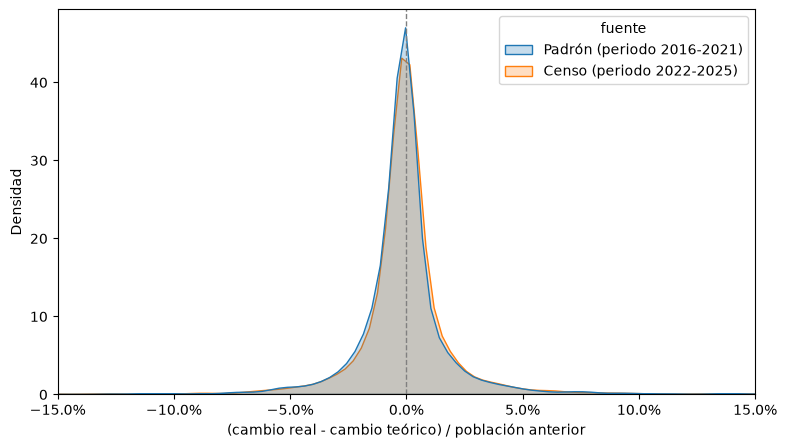

In [37]:

d = aux[~aux["cod_mun"].isin(PROV_CLM)].replace([np.inf, -np.inf], np.nan).dropna(subset=["p_diferencia"])
d["fuente"] = np.where(d["periodo"] <= 2021, "Padrón (periodo 2016-2021)", "Censo (periodo 2022-2025)")

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=d, x="p_diferencia", hue="fuente", common_norm=False, fill=True, ax=ax)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set(xlim=(-0.15, 0.15), xlabel="(cambio real - cambio teórico) / población anterior", ylabel="Densidad")
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.show()

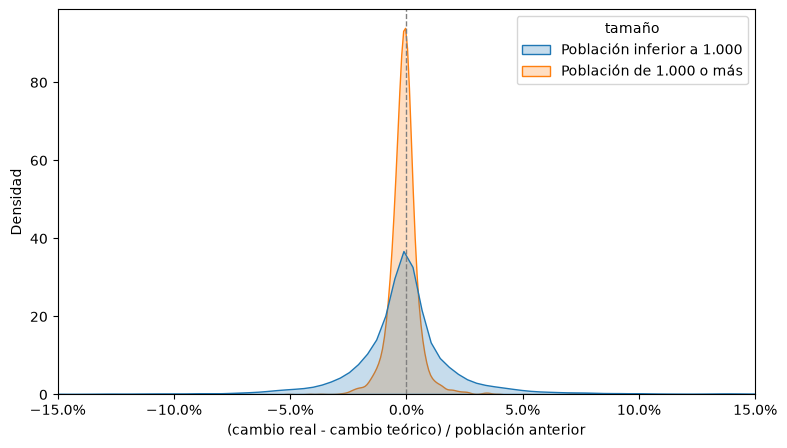

In [38]:
d = aux[~aux["cod_mun"].isin(PROV_CLM)].replace([np.inf, -np.inf], np.nan).dropna(subset=["p_diferencia"])
d["tamaño"] = np.where(d["total"] < 1_000, "Población inferior a 1.000", "Población de 1.000 o más")

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=d, x="p_diferencia", hue="tamaño", common_norm=False, fill=True, ax=ax)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set(xlim=(-0.15, 0.15), xlabel="(cambio real - cambio teórico) / población anterior", ylabel="Densidad")
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.show()

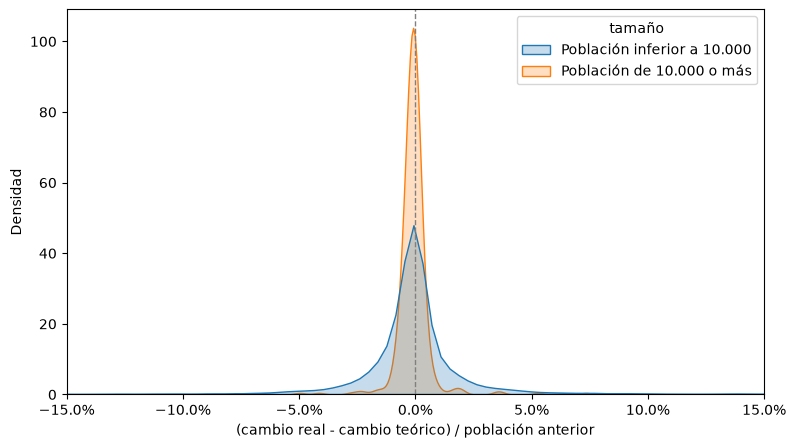

In [39]:
d = aux[~aux["cod_mun"].isin(PROV_CLM)].replace([np.inf, -np.inf], np.nan).dropna(subset=["p_diferencia"])
d["tamaño"] = np.where(d["total"] < 10_000, "Población inferior a 10.000", "Población de 10.000 o más")

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=d, x="p_diferencia", hue="tamaño", common_norm=False, fill=True, ax=ax)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set(xlim=(-0.15, 0.15), xlabel="(cambio real - cambio teórico) / población anterior", ylabel="Densidad")
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.show()

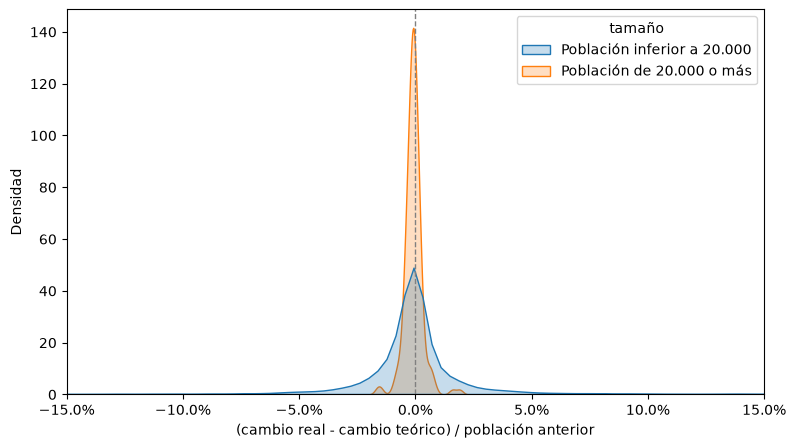

In [40]:
d = aux[~aux["cod_mun"].isin(PROV_CLM)].replace([np.inf, -np.inf], np.nan).dropna(subset=["p_diferencia"])
d["tamaño"] = np.where(d["total"] < 20_000, "Población inferior a 20.000", "Población de 20.000 o más")

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=d, x="p_diferencia", hue="tamaño", common_norm=False, fill=True, ax=ax)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set(xlim=(-0.15, 0.15), xlabel="(cambio real - cambio teórico) / población anterior", ylabel="Densidad")
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.show()

In [41]:
aux[aux["total"] >= 20_000].count()

cod_mun           160
periodo           160
nombre            160
total             160
total_anterior    160
cambio_real       160
cambio_teorico    160
diferencia        160
p_diferencia      160
dtype: int64

## 6.2. Aumentando el periodo de tiempo 

In [42]:
df.columns[df.columns.str.contains("suma")]

Index(['suma_altas_int_5', 'p_suma_altas_int_5', 'suma_altas_ext_5',
       'p_suma_altas_ext_5', 'suma_bajas_int_5', 'p_suma_bajas_int_5',
       'suma_bajas_ext_5', 'p_suma_bajas_ext_5', 'suma_altas_int_10',
       'p_suma_altas_int_10', 'suma_altas_ext_10', 'p_suma_altas_ext_10',
       'suma_bajas_int_10', 'p_suma_bajas_int_10', 'suma_bajas_ext_10',
       'p_suma_bajas_ext_10', 'suma_mnp_nacimientos_5',
       'p_suma_mnp_nacimientos_5', 'suma_mnp_fallecidos_5',
       'p_suma_mnp_fallecidos_5', 'suma_mnp_crecimiento_veg_5',
       'p_suma_mnp_crecimiento_veg_5', 'suma_mnp_nacimientos_10',
       'p_suma_mnp_nacimientos_10', 'suma_mnp_fallecidos_10',
       'p_suma_mnp_fallecidos_10', 'suma_mnp_crecimiento_veg_10',
       'p_suma_mnp_crecimiento_veg_10'],
      dtype='str')

In [43]:
aux = df.sort_values(["cod_mun", "periodo"]).copy()
aux = aux[aux["cod_mun"] != aux["cod_prov"]]

# aux["altas_ext"] = aux[".groupby("cod_mun")["altas_ext"].shift(1)"]
# aux["altas_int"] = aux.groupby("cod_mun")["altas_int"].shift(1)
# aux["bajas_ext"] = aux.groupby("cod_mun")["bajas_ext"].shift(1)
# aux["bajas_int"] = aux.groupby("cod_mun")["bajas_int"].shift(1)
# aux["mnp_crecimiento_veg"] = aux.groupby("cod_mun")["mnp_crecimiento_veg"].shift(1)

aux["altas_totales_5"]  = aux["suma_altas_int_5"] + aux["suma_altas_ext_5"]
aux["bajas_totales_5"]  = aux["suma_bajas_int_5"] + aux["suma_bajas_ext_5"]
aux["altas_totales_10"] = aux["suma_altas_int_10"] + aux["suma_altas_ext_10"]
aux["bajas_totales_10"] = aux["suma_bajas_int_10"] + aux["suma_bajas_ext_10"]

aux["saldo_total_5"]    = aux["altas_totales_5"] - aux["bajas_totales_5"]
aux["saldo_total_10"]   = aux["altas_totales_10"] - aux["bajas_totales_10"]

aux["cambio_teorico_5"]  = aux["saldo_total_5"] + aux["suma_mnp_crecimiento_veg_5"]
aux["cambio_teorico_10"] = aux["saldo_total_10"] + aux["suma_mnp_crecimiento_veg_10"]


aux["total_anterior_5"]  = aux.groupby("cod_mun")["total"].shift(5)
aux["total_anterior_10"] = aux.groupby("cod_mun")["total"].shift(10)

aux["cambio_real_5"]  = aux["total"] - aux["total_anterior_5"]
aux["cambio_real_10"] = aux["total"] - aux["total_anterior_10"]

aux["diferencia_5"]  = aux["cambio_real_5"] - aux["cambio_teorico_5"]
aux["diferencia_10"] = aux["cambio_real_10"] - aux["cambio_teorico_10"]

aux["p_diferencia_5"] = aux["diferencia_5"] / aux["total_anterior_5"]
aux["p_diferencia_10"] = aux["diferencia_10"] / aux["total_anterior_10"]

aux = aux[aux[["p_diferencia_5", "p_diferencia_10"]].notna().any(axis=1)]
aux = aux[[
    "cod_mun", "periodo", "nombre", "total",
    "total_anterior_5", "cambio_real_5", "cambio_teorico_5", "diferencia_5", "p_diferencia_5",
    "total_anterior_10", "cambio_real_10", "cambio_teorico_10", "diferencia_10", "p_diferencia_10",
]]
aux = aux[aux["periodo"] == 2025]
aux.head()

,cod_mun,periodo,nombre,total,total_anterior_5,cambio_real_5,cambio_teorico_5,diferencia_5,p_diferencia_5,total_anterior_10,cambio_real_10,cambio_teorico_10,diferencia_10,p_diferencia_10
51,02001,2025,Abengibre,753.0,761.0,-8.0,-11.0,3.0,0.003942,782.0,-29.0,-39.0,10.0,0.012788
77,02002,2025,Alatoz,504.0,506.0,-2.0,-24.0,22.0,0.043478,610.0,-106.0,-100.0,-6.0,-0.009836
103,02003,2025,Albacete,175400.0,174336.0,1064.0,1654.0,-590.0,-0.003384,172121.0,3279.0,4770.0,-1491.0,-0.008663
129,02004,2025,Albatana,644.0,679.0,-35.0,-20.0,-15.0,-0.022091,744.0,-100.0,-70.0,-30.0,-0.040323
155,02005,2025,Alborea,672.0,664.0,8.0,10.0,-2.0,-0.003012,754.0,-82.0,-47.0,-35.0,-0.046419


### 6.2.1. Casos con mayor diferencia

In [44]:
aux.loc[aux["p_diferencia_10"].abs().nlargest(20).index]

,cod_mun,periodo,nombre,total,total_anterior_5,cambio_real_5,cambio_teorico_5,diferencia_5,p_diferencia_5,total_anterior_10,cambio_real_10,cambio_teorico_10,diferencia_10,p_diferencia_10
17419,19279,2025,Torre del Burgo,494.0,611.0,-117.0,37.0,-154.0,-0.252046,228.0,266.0,689.0,-423.0,-1.855263
9983,16231,2025,Valhermoso de la Fuente,61.0,52.0,9.0,-6.0,15.0,0.288462,55.0,6.0,-19.0,25.0,0.454545
14039,19133,2025,Heras de Ayuso,248.0,255.0,-7.0,8.0,-15.0,-0.058824,252.0,-4.0,102.0,-106.0,-0.420635
9073,16177,2025,Reíllo,106.0,116.0,-10.0,-7.0,-3.0,-0.025862,89.0,17.0,-14.0,31.0,0.348315
10815,16275,2025,Vindel,19.0,11.0,8.0,5.0,3.0,0.272727,12.0,7.0,3.0,4.0,0.333333
11907,19034,2025,Anquela del Pedregal,28.0,29.0,-1.0,-4.0,3.0,0.103448,19.0,9.0,3.0,6.0,0.315789
18147,19309,2025,Valhermoso,15.0,22.0,-7.0,-3.0,-4.0,-0.181818,44.0,-29.0,-16.0,-13.0,-0.295455
17081,19263,2025,Taragudo,45.0,44.0,1.0,3.0,-2.0,-0.045455,51.0,-6.0,9.0,-15.0,-0.294118
8449,16151,2025,Paredes,61.0,58.0,3.0,-8.0,11.0,0.189655,65.0,-4.0,-22.0,18.0,0.276923
9489,16199,2025,Solera de Gabaldón,32.0,27.0,5.0,2.0,3.0,0.111111,29.0,3.0,-5.0,8.0,0.275862


 ### 6.2.2. Distribución

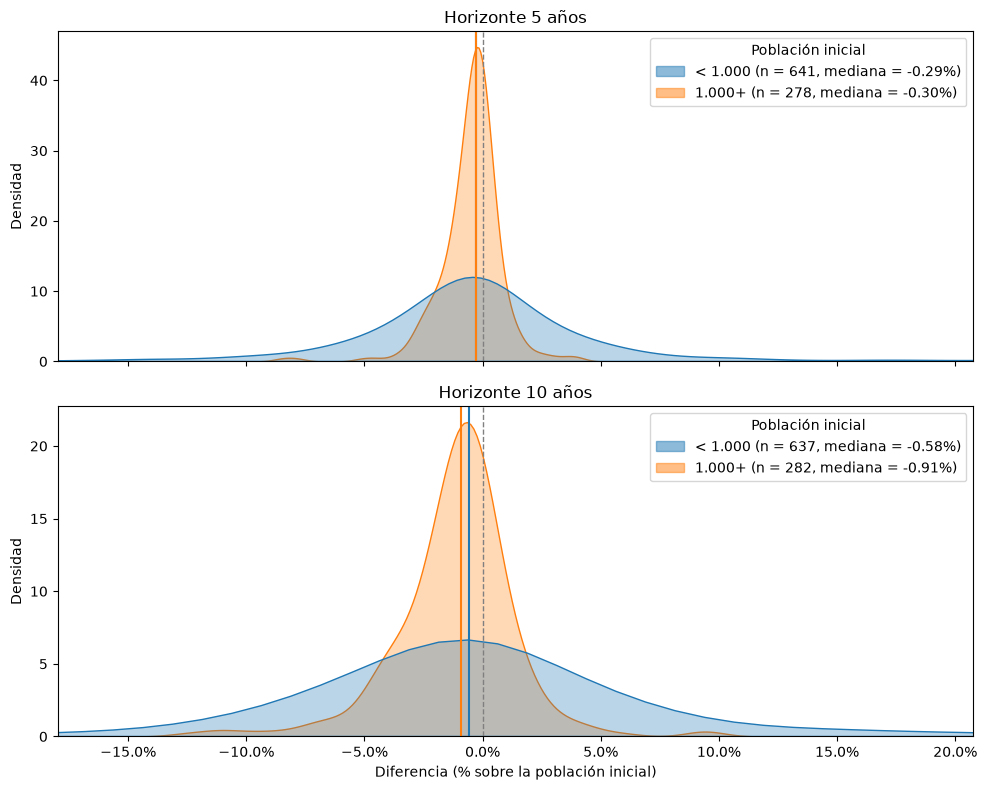

In [45]:
horizontes = [5, 10]
orden_tam = ["< 1.000", "1.000+"]
paleta = dict(zip(orden_tam, sns.color_palette("tab10", 2)))

fig, axes = plt.subplots(len(horizontes), 1, figsize=(10, 4 * len(horizontes)), sharex=True)

for ax, k in zip(axes, horizontes):
    col = f"p_diferencia_{k}"
    d = aux[[col, f"total_anterior_{k}"]].dropna().copy()
    d["tamano"] = pd.Categorical(
        np.where(d[f"total_anterior_{k}"] < 1000, "< 1.000", "1.000+"),
        categories=orden_tam
    )

    sns.kdeplot(
        data=d, x=col, hue="tamano", hue_order=orden_tam, palette=paleta,
        common_norm=False, fill=True, alpha=0.3, ax=ax
    )

    ax.axvline(0, color="grey", linestyle="--", linewidth=1)
    for tam in orden_tam:
        ax.axvline(d.loc[d["tamano"] == tam, col].median(), color=paleta[tam], linewidth=1.5)

    etiquetas = [
        f"{tam} (n = {(d['tamano'] == tam).sum():,}, mediana = {d.loc[d['tamano'] == tam, col].median():.2%})"
        for tam in orden_tam
    ]
    handles = [plt.Rectangle((0, 0), 1, 1, color=paleta[t], alpha=0.5) for t in orden_tam]
    ax.legend(handles, etiquetas, title="Población inicial", loc="upper right")

    ax.set_title(f"Horizonte {k} años")
    ax.set_ylabel("Densidad")

# Rango común de percentiles 1–99
valores = aux[[f"p_diferencia_{k}" for k in horizontes]].stack()
axes[-1].set_xlim(valores.quantile(0.01), valores.quantile(0.99))
axes[-1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[-1].set_xlabel("Diferencia (% sobre la población inicial)")

# fig.suptitle("Distribución de p_diferencia por horizonte y tamaño de municipio", fontsize=14)
plt.tight_layout()
plt.show()